# Шапка

ML-HW06-v1 TEAM-11. translate-colab.
- Руденко Евгений Александрович
- Сажин Семён Михайлович
- Тихомиров Алексей Константинович

In [3]:
#!pip install -q --upgrade nltk gensim bokeh pandas

import nltk
nltk.download('punkt')
nltk.download('stopwords')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 71.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 116.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 112.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
dask-cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.
panel 1.9.4 requires bokeh<3.10.0,>=3.7.0, but you have bokeh 3.10.0 which is incompatible.
cudf-cu13 26.6.0 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.6 which is incompatible.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import pandas as pd
import numpy as np
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.manifold import TSNE


In [5]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from string import punctuation


## Запилим пословный машинный перевод!


In [6]:
#!wget -O ukr_rus.train.txt -qq --no-check-certificate "https://drive.google.com/uc?export=download&id=1vAK0SWXUqei4zTimMvIhH3ufGPsbnC_O"
#!wget -O ukr_rus.test.txt -qq --no-check-certificate "https://drive.google.com/uc?export=download&id=1W9R2F8OeKHXruo2sicZ6FgBJUTJc8Us_"
#!wget -O fairy_tale.txt -qq --no-check-certificate "https://drive.google.com/uc?export=download&id=1sq8zSroFeg_afw-60OmY8RATdu_T1tej"


#!wget -O cc.ru.300.vec.gz -q "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ru.300.vec.gz"
#!wget -O cc.uk.300.vec.gz -q "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.uk.300.vec.gz"

#!gunzip -f cc.ru.300.vec.gz
#!gunzip -f cc.uk.300.vec.gz

In [7]:
from pathlib import Path

needed = [
    "ukr_rus.train.txt",
    "ukr_rus.test.txt",
    "fairy_tale.txt",
    "cc.ru.300.vec",
    "cc.uk.300.vec",
]
missing = [name for name in needed if not Path(name).exists()]
if missing:
    raise FileNotFoundError("Рядом с ноутбуком нет файлов: " + ", ".join(missing))
print("данные на месте")


данные на месте


Напишем простенькую реализацию модели машинного перевода.

Идея основана на статье [Word Translation Without Parallel Data](https://arxiv.org/pdf/1710.04087.pdf). У авторов в репозитории еще много интересного: [https://github.com/facebookresearch/MUSE](https://github.com/facebookresearch/MUSE).

А мы будем переводить с украинского на русский.

![](https://raw.githubusercontent.com/yandexdataschool/nlp_course/master/resources/blue_cat_blue_whale.png)   
*синій кіт* vs. *синій кит*


In [8]:
from gensim.models import KeyedVectors

ru_emb = KeyedVectors.load_word2vec_format("cc.ru.300.vec")
uk_emb = KeyedVectors.load_word2vec_format("cc.uk.300.vec")


Посмотрим на пару серпень-август (являющихся переводом)


In [9]:
ru_emb.most_similar([ru_emb["август"]])


[('август', 1.0000001192092896),
 ('июль', 0.9383152723312378),
 ('сентябрь', 0.9240029454231262),
 ('июнь', 0.9222574830055237),
 ('октябрь', 0.9095539450645447),
 ('ноябрь', 0.8930036425590515),
 ('апрель', 0.8729087114334106),
 ('декабрь', 0.8652557730674744),
 ('март', 0.8545795679092407),
 ('февраль', 0.8401415944099426)]

In [10]:
uk_emb.most_similar([uk_emb["серпень"]])


[('серпень', 0.9999998807907104),
 ('липень', 0.9096441268920898),
 ('вересень', 0.9016969203948975),
 ('червень', 0.8992518782615662),
 ('жовтень', 0.8810408115386963),
 ('листопад', 0.8787633180618286),
 ('квітень', 0.8592804670333862),
 ('грудень', 0.8586863279342651),
 ('травень', 0.840811014175415),
 ('лютий', 0.8256431221961975)]

In [11]:
ru_emb.most_similar([uk_emb["серпень"]])


[('Stepashka.com', 0.2757962644100189),
 ('ЖИЗНИВадим', 0.25203436613082886),
 ('2Дмитрий', 0.25048112869262695),
 ('2012Дмитрий', 0.24829229712486267),
 ('Ведущий-Алексей', 0.24438698589801788),
 ('Недопустимость', 0.24435284733772278),
 ('2Михаил', 0.23981398344039917),
 ('лексей', 0.23740755021572113),
 ('комплексн', 0.23695150017738342),
 ('персональ', 0.2368222326040268)]

In [21]:
def load_word_pairs(filename):
    uk_ru_pairs = []
    uk_vectors = []
    ru_vectors = []
    with open(filename, "r", encoding='utf8') as inpf:
        for line in inpf:
            uk, ru = line.rstrip().split("\t")
            if uk not in uk_emb or ru not in ru_emb:
                continue
            uk_ru_pairs.append((uk, ru))
            uk_vectors.append(uk_emb[uk])
            ru_vectors.append(ru_emb[ru])
    return uk_ru_pairs, np.array(uk_vectors), np.array(ru_vectors)


uk_ru_train, X_train, Y_train = load_word_pairs("ukr_rus.train.txt")
uk_ru_test, X_test, Y_test = load_word_pairs("ukr_rus.test.txt")


### Учим маппинг из одного пространства эмбеддингов в другое

У нас есть пары слов, соответствующих друг другу, и их эмбеддинги. Найдем преобразование из одного пространства в другое, чтобы приблизить известные нам слова:

$$W^*= \arg\min_W ||WX - Y||_F, \text{где} ||*||_F - \text{норма Фробениуса}$$

Эта функция очень похожа на линейную регрессию (без биаса).

**Задание** Реализуйте её - воспользуйтесь `LinearRegression` из sklearn с `fit_intercept=False`:


In [23]:
from sklearn.linear_model import LinearRegression

mapping = LinearRegression(fit_intercept=False)
mapping.fit(X_train, Y_train)


LinearRegression(fit_intercept=False)

**Комментарий к заданию.** Линейная регрессия без свободного члена ищет матрицу, которая переводит украинские векторы в русские и минимизирует ошибку по всем координатам. В коде векторы лежат строками, поэтому обучается отображение $XW \approx Y$. Свободный член выключен: сдвиг всего облака не совмещает направления слов. «Серпень» после этого попадает к русским месяцам, но «август» ещё не первый сосед.


Проверим, куда перейдет `серпень`:


In [24]:
august = mapping.predict(uk_emb["серпень"].reshape(1, -1))
ru_emb.most_similar(august)


[('апрель', 0.8531431555747986),
 ('июнь', 0.8402523398399353),
 ('март', 0.8385884761810303),
 ('сентябрь', 0.8331484198570251),
 ('февраль', 0.8311208486557007),
 ('октябрь', 0.8278018236160278),
 ('ноябрь', 0.8243727087974548),
 ('июль', 0.822961688041687),
 ('август', 0.8112279772758484),
 ('январь', 0.8022984862327576)]

Должно получиться, что в топе содержатся разные месяцы, но август не первый.

Будем мерять percision top-k с k = 1, 5, 10.

**Задание** Реализуйте следующую функцию:


In [26]:
def precision(pairs, mapped_vectors, topn=1):
    """
    :args:
        pairs = list of right word pairs [(uk_word_0, ru_word_0), ...]
        mapped_vectors = list of embeddings after mapping from source embedding space to destination embedding space
        topn = the number of nearest neighbours in destination embedding space to choose from
    :returns:
        precision_val, float number, total number of words for those we can find right translation at top K.
    """
    assert len(pairs) == len(mapped_vectors)
    num_matches = 0
    for i, (_, ru) in enumerate(pairs):
        neighbours = ru_emb.most_similar([mapped_vectors[i]], topn=topn)
        if any(word == ru for word, _ in neighbours):
            num_matches += 1
    precision_val = num_matches / len(pairs)
    return precision_val


**Комментарий к заданию.** Precision@k — доля украинских слов, чей русский перевод попал в k ближайших соседей. В шаблоне сравнивалась длина с `ru_vectors`, но эта переменная есть только внутри `load_word_pairs`, поэтому проверка идёт по `mapped_vectors`. Без маппинга точность на тесте 0, на самих русских векторах она 1. У «серпень» «август» не входит в топ-5 и входит в топ-9. Линейный маппинг даёт precision@1 = 0.6565 и precision@5 = 0.8270.


### Подбор значения k для Precision@k

Проверим на тестовой выборке, как меняется качество при разных значениях `k` (1, 5 и 10) для линейного и ортогонального отображений.

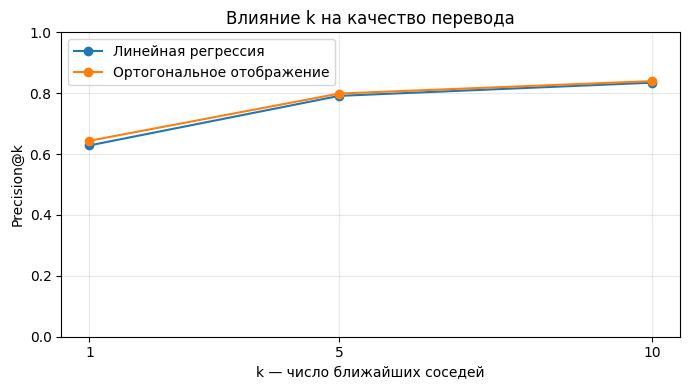

In [38]:
k_values = [1, 5, 10]
linear_scores = [precision(uk_ru_test, mapping.predict(X_test), k) for k in k_values]
orthogonal_scores = [precision(uk_ru_test, X_test @ W, k) for k in k_values]

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(k_values, linear_scores, marker="o", label="Линейная регрессия")
plt.plot(k_values, orthogonal_scores, marker="o", label="Ортогональное отображение")
plt.xticks(k_values)
plt.ylim(0, 1)
plt.xlabel("k — число ближайших соседей")
plt.ylabel("Precision@k")
plt.title("Влияние k на качество перевода")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
assert precision([("серпень", "август")], august, topn=5) == 0.0
assert precision([("серпень", "август")], august, topn=9) == 1.0
assert precision([("серпень", "август")], august, topn=10) == 1.0


In [28]:
assert precision(uk_ru_test, X_test) == 0.0
assert precision(uk_ru_test, Y_test) == 1.0


In [32]:
precision_top1 = precision(uk_ru_test, mapping.predict(X_test), 1)
precision_top5 = precision(uk_ru_test, mapping.predict(X_test), 5)

assert precision_top1 >= 0.635
assert precision_top5 >= 0.813


### Улучшаем маппинг

Можно показать, что маппинг лучше строить ортогональным:
$$W^*= \arg\min_W ||WX - Y||_F \text{, где: } W^TW = I$$

Искать его можно через SVD:
$$X^TY=U\Sigma V^T\text{, singular value decompostion}$$

$$W^*=UV^T$$

**Задание** Реализуйте эту функцию.


In [33]:
def learn_transform(X_train, Y_train):
    """
    :returns: W* : float matrix[emb_dim x emb_dim] as defined in formulae above
    """
    u, _, vt = np.linalg.svd(np.matmul(X_train.T, Y_train), full_matrices=False)
    return np.matmul(u, vt)


**Комментарий к заданию.** Ортогональное преобразование — поворот без растяжения, поэтому соседства внутри языка сохраняются лучше, чем у обычной регрессии. Из SVD $X^T Y = U \Sigma V^T$ берётся $W = UV^T$. `np.linalg.svd` сразу возвращает $V^T$, в коде это `vt`. На тесте precision@1 = 0.6743 и precision@5 = 0.8321.


In [34]:
W = learn_transform(X_train, Y_train)


In [35]:
ru_emb.most_similar([np.matmul(uk_emb["серпень"], W)])


[('апрель', 0.8245132565498352),
 ('июнь', 0.8056628704071045),
 ('сентябрь', 0.8055762648582458),
 ('март', 0.8032935261726379),
 ('октябрь', 0.798710286617279),
 ('июль', 0.794679582118988),
 ('ноябрь', 0.7939637899398804),
 ('август', 0.7938188314437866),
 ('февраль', 0.7923861742019653),
 ('декабрь', 0.7715376019477844)]

In [37]:
assert precision(uk_ru_test, np.matmul(X_test, W)) >= 0.653
assert precision(uk_ru_test, np.matmul(X_test, W), 5) >= 0.824


### Выбор модели отображения

Сравним отсутствие обучения, линейную регрессию со свободным членом и без него, а также ортогональное отображение. Это позволяет проверить, оправданы ли выбранные ограничения модели.

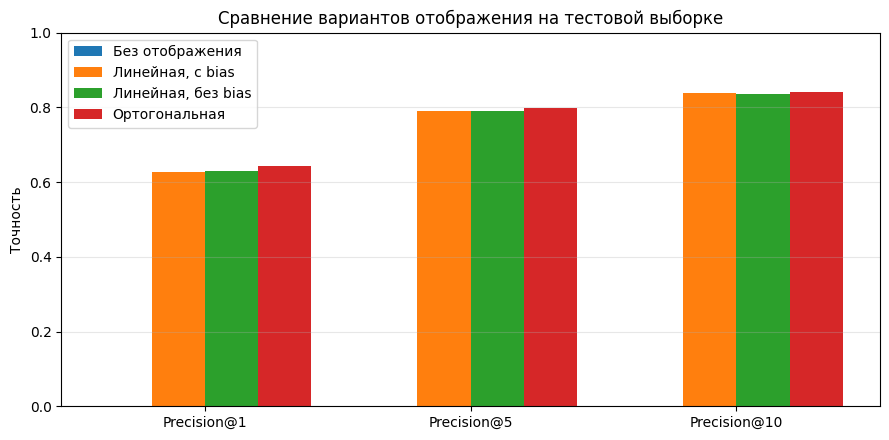

In [39]:
from sklearn.linear_model import LinearRegression

# Базовый вариант: не преобразуем украинские векторы.
identity_scores = [precision(uk_ru_test, X_test, k) for k in k_values]

# Проверяем, влияет ли свободный член на качество.
mapping_with_intercept = LinearRegression(fit_intercept=True)
mapping_with_intercept.fit(X_train, Y_train)
intercept_scores = [
    precision(uk_ru_test, mapping_with_intercept.predict(X_test), k)
    for k in k_values
]

linear_scores_model = [precision(uk_ru_test, mapping.predict(X_test), k) for k in k_values]
orthogonal_scores_model = [precision(uk_ru_test, X_test @ W, k) for k in k_values]

x = np.arange(len(k_values))
width = 0.2
plt.figure(figsize=(9, 4.5))
plt.bar(x - 1.5*width, identity_scores, width, label="Без отображения")
plt.bar(x - 0.5*width, intercept_scores, width, label="Линейная, с bias")
plt.bar(x + 0.5*width, linear_scores_model, width, label="Линейная, без bias")
plt.bar(x + 1.5*width, orthogonal_scores_model, width, label="Ортогональная")
plt.xticks(x, [f"Precision@{k}" for k in k_values])
plt.ylim(0, 1)
plt.ylabel("Точность")
plt.title("Сравнение вариантов отображения на тестовой выборке")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Комментарий к графику.** Сравнение построено на одной тестовой выборке и по одинаковым метрикам, поэтому варианты можно сопоставлять напрямую. Базовый вариант без отображения показывает, насколько плохо совпадают исходные пространства эмбеддингов. Свободный член проверяется экспериментально: если он не улучшает метрику, дополнительный сдвиг не нужен. Ортогональное отображение ограничивает преобразование сохранением геометрии (не растягивает пространство), что мотивировано задачей совмещения пространств эмбеддингов. Предпочитать следует вариант, который показывает более высокие Precision@k на тесте; если разница небольшая, ортогональное ограничение дополнительно имеет содержательное обоснование — оно лучше сохраняет расстояния и соседства.

### Пишем переводчик


Реализуем простой пословный переводчик - для каждого слова будем искать его ближайшего соседа в общем пространстве эмбеддингов. Если слова нет в эмбеддингах - просто копируем его.


In [40]:
with open("fairy_tale.txt", "r", encoding="utf-8") as inf:
    uk_sentences = [line.rstrip().lower() for line in inf]


In [41]:
def translate(sentence):
    """
    :args:
        sentence - sentence in Ukrainian (str)
    :returns:
        translation - sentence in Russian (str)

    * find ukrainian embedding for each word in sentence
    * transform ukrainian embedding vector
    * find nearest russian word and replace
    """
    translated = []
    for word in sentence.split(" "):
        if word not in uk_emb:
            translated.append(word)
            continue
        mapped = np.matmul(uk_emb[word], W)
        translated.append(ru_emb.most_similar([mapped], topn=1)[0][0])
    return " ".join(translated)


**Комментарий к заданию.** Фраза режется по пробелам. Если украинское слово есть в эмбеддингах, его вектор умножается на $W$ и заменяется ближайшим русским словом. Числа и знаки препинания копируются, поэтому `«.»` и `«1 , 3»` не меняются. `«кіт зловив мишу»` становится `«кот поймал мышку»`. На сказке это черновой подстрочник без грамматики.


In [42]:
assert translate(".") == "."
assert translate("1 , 3") == "1 , 3"
assert translate("кіт зловив мишу") == "кот поймал мышку"


In [43]:
for sentence in uk_sentences:
    print("src: {}\ndst: {}\n".format(sentence, translate(sentence)))


src: лисичка - сестричка і вовк - панібрат
dst: лисичка – сестричка и волк – панібрат

src: як була собі лисичка , да й пішла раз до однії баби добувать огню ; ввійшла у хату да й каже : " добрий день тобі , бабусю !
dst: как была себе лисичка , че и пошла раз к обеих бабы добывать огнь ; вошла во избу че и говорит : " хороший день тебе , бабушку !

src: дай мені огня " .
dst: дай мне огня " .

src: а баба тільки що вийняла із печі пирожок із маком , солодкий , да й положила , щоб він прохолов ; а лисичка се і підгледала , да тілько що баба нахилилась у піч , щоб достать огня , то лисичка зараз ухватила пирожок да і драла з хати , да , біжучи , весь мак із його виїла , а туда сміття наклала .
dst: а бабка только что вынула со печи самогончик со маком , сладкий , че и прогнула , чтобы он успокоился ; а лисичка ой и підгледала , че токмо что бабка свесилась во печь , чтобы прость огня , то лисичка сейчас ухватила самогончик че и дунула со хаты , че , пробежать , весь мак со его кринки , 

# Дополнительные материалы


## Почитать
### База:  
[On word embeddings - Part 1, Sebastian Ruder](http://ruder.io/word-embeddings-1/)  
[Deep Learning, NLP, and Representations, Christopher Olah](http://colah.github.io/posts/2014-07-NLP-RNNs-Representations/)  

### Как кластеризовать смыслы многозначных слов:  
[Making Sense of Word Embeddings (2016), Pelevina et al](http://anthology.aclweb.org/W16-1620)    

### Как оценивать эмбеддинги
[Evaluation methods for unsupervised word embeddings (2015), T. Schnabel](http://www.aclweb.org/anthology/D15-1036)  
[Intrinsic Evaluation of Word Vectors Fails to Predict Extrinsic Performance (2016), B. Chiu](https://www.aclweb.org/anthology/W/W16/W16-2501.pdf)  
[Problems With Evaluation of Word Embeddings Using Word Similarity Tasks (2016), M. Faruqui](https://arxiv.org/pdf/1605.02276.pdf)  
[Improving Reliability of Word Similarity Evaluation by Redesigning Annotation Task and Performance Measure (2016), Oded Avraham, Yoav Goldberg](https://arxiv.org/pdf/1611.03641.pdf)  
[Evaluating Word Embeddings Using a Representative Suite of Practical Tasks (2016), N. Nayak](https://cs.stanford.edu/~angeli/papers/2016-acl-veceval.pdf)  


## Посмотреть
[Word Vector Representations: word2vec, Lecture 2, cs224n](https://www.youtube.com/watch?v=ERibwqs9p38)
